In [1]:
import pandas as pd
df = pd.read_csv('TheTitanicCleaned.csv')

### Univariate Analysis

#### 1. Survived
Seeing the exact ratio of Survived v/s Perished

C:\Users\rashm\AppData\Local\Temp\ipykernel_24724\1571483320.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x = "Survived", palette= paletteP)


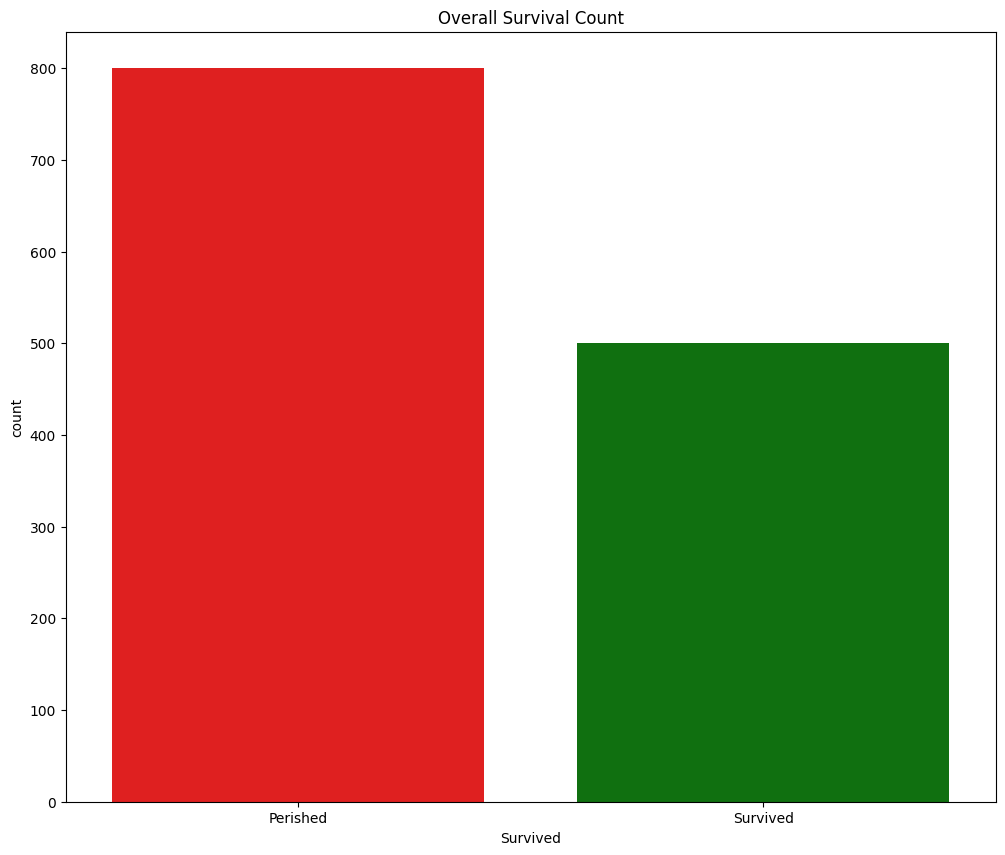

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))
paletteP = ['r','g']
sns.countplot(data = df, x = "Survived", palette= paletteP)
plt.xticks([0,1],['Perished', 'Survived']) # 0 = Perished, 1 = Survived 
plt.title('Overall Survival Count')
plt.show()

#### 2. Numerical Distribution
Checking how continuous the Age and Fare are, after cleaning, using Histograms.

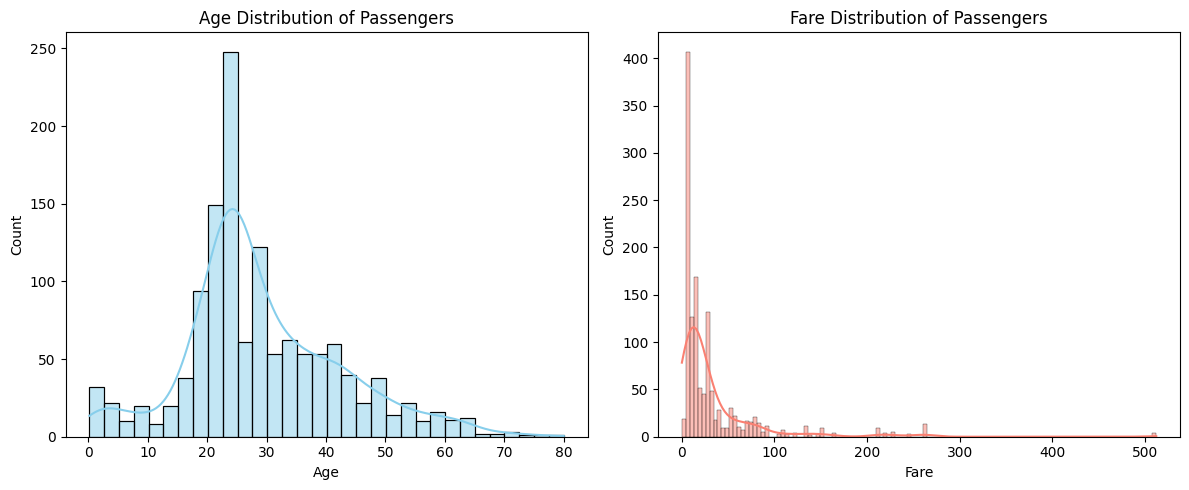

In [23]:
# Creating a plot with 2 subplots in the form of 1 row and 2 columns and total plot size 12 x 5
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 

# Age Distribution

## Creating a histogram with dataset 'df', 'Age' on the x-axis
sns.histplot(data=df, x='Age', kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Age Distribution of Passengers')

# Fare Distribution

## Creating a histogram with dataset 'df', 'Fare' on the x-axis
sns.histplot(data=df, x='Fare', kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Fare Distribution of Passengers')

# 'kde' attribute is for drawing the bell-curve on the histogram, connecting distinct values in a continuous manner
# 'ax' attribute is for choosing a subplot area and 'axes' is for choosing the subplot - axes[0]: 1st subplot, axes[1]: 2nd subplot
plt.tight_layout() 
# tight_layout() is for wrapping the subplots in minimal area while also ensuring they don't overlap. It reduces the padding between the two subplots.
plt.show()

### Bivariate Analysis

#### 1. Gender v/s Survived
Finding the relation between Gender and Survival Rate. Checking if the gender of the passengers had any affect in their survival. Did women and children have better survival rates?

C:\Users\rashm\AppData\Local\Temp\ipykernel_24724\4010867825.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df, x = 'Gender', y = df['Survived']*100, palette = palette2)


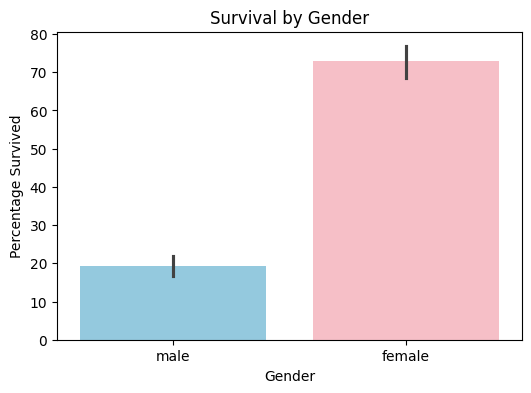

In [30]:
plt.figure(figsize=(6,4))
palette2 = ['skyblue','lightpink']
sns.barplot(data = df, x = 'Gender', y = df['Survived']*100, palette = palette2)
plt.title('Survival by Gender')
plt.ylabel('Percentage Survived')
plt.show()

#### 2. Passenger Class v/s Survived
Finding the relation between Passenger Class and Survival Rate. Checking if the wealth of the passengers had any affect in their survival. Did the wealthy better survival rates? Were the poor left to die?

C:\Users\rashm\AppData\Local\Temp\ipykernel_24724\2553969111.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df, x = 'Pclass', y = df['Survived']*100, palette = palette3)


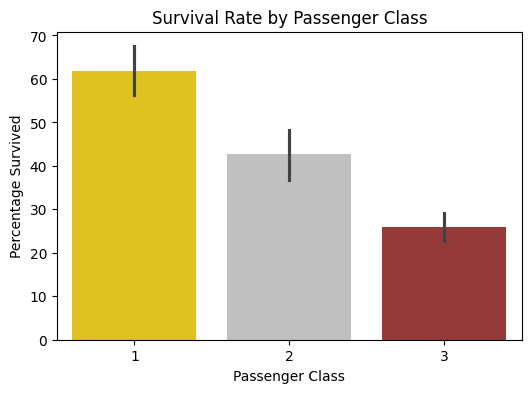

In [34]:
plt.figure(figsize = (6,4))
palette3 = ['gold', 'silver', 'brown']
sns.barplot(data = df, x = 'Pclass', y = df['Survived']*100, palette = palette3)
plt.xlabel('Passenger Class')
plt.ylabel('Percentage Survived')
plt.title('Survival Rate by Passenger Class')
plt.show()

#### 3. Family v/s Survived
Finding the relation between the Number of Family Members Onboard and Survival Rate. Did having multiple family members onboard reduced the rate of survival?

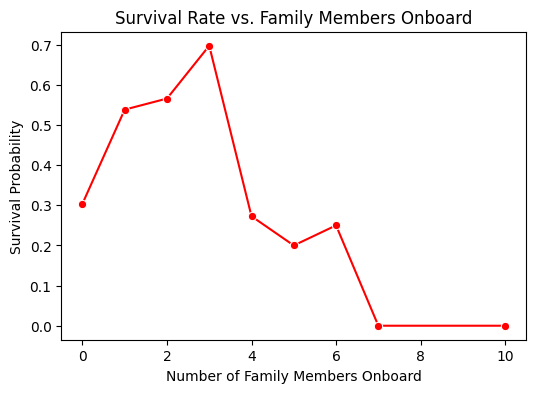

In [41]:
plt.figure(figsize=(6, 4))
sns.lineplot(data=df, x='Family', y='Survived', marker='o', color='red', errorbar=None)
plt.title('Survival Rate vs. Family Members Onboard')
plt.xlabel('Number of Family Members Onboard')
plt.ylabel('Survival Probability')
plt.show()

### Multivariate Analysis

#### 1. Interaction of Class, Gender and Survival
Women survived better than men, and 1st class better than 3rd class. But what happened to 3rd-class women? Or 1st-class men?

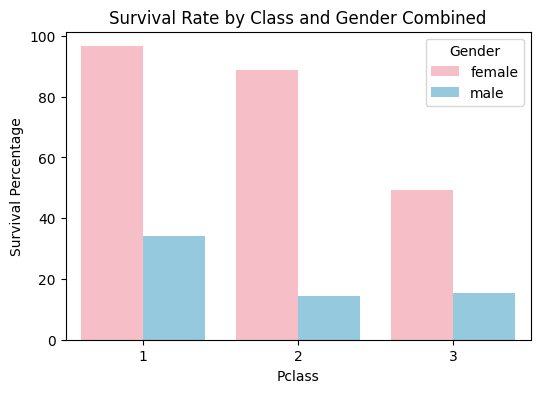

In [47]:
plt.figure(figsize = (6,4))
palette4 = ['lightpink', 'skyblue']
sns.barplot(data = df, x = 'Pclass', y = df['Survived']*100, hue = 'Gender', palette  = palette4, errorbar = None)
#  Setting 'errorbar=None' removes the statistical whiskers entirely, leaving just the point or bar representing the central tendency.
# 'hue' is a parameter used to color-code data points based on a categorical variable.
plt.title('Survival Rate by Class and Gender Combined')
plt.ylabel('Survival Percentage')
plt.show()

#### 2. Correlation Matrix
Checking how all the numerical columns relate to eachother using a correlation heatmap.

In [55]:
corrDf = df.copy()

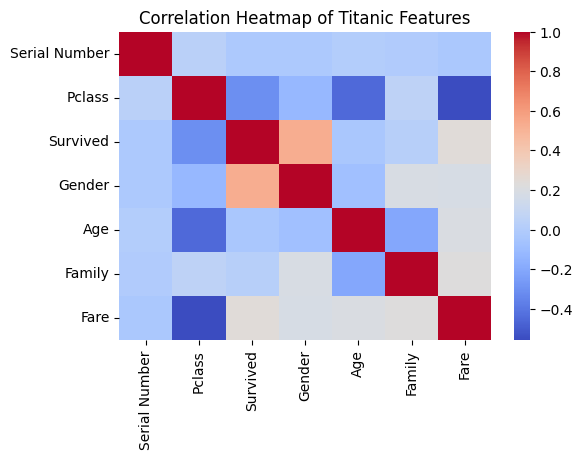

In [56]:
# We need to convert the columns with categorical data into numberic data
corrDf['Gender'] = corrDf['Gender'].map({'male':0, 'female':1})

# Selecting only numeric columns
numCols = corrDf.select_dtypes('number')

# Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(numCols.corr(), cmap = 'coolwarm')
plt.title('Correlation Heatmap of Titanic Features')
plt.show()